# Lab 1
## Dynamic model of a multi-link manipulator

## Steps

### 0. Import the necessary libraries

In [1059]:
from math import pi
import numpy as np
import roboticstoolbox as rtb
import matplotlib.pyplot as plt

### 1. Import robot model (Standford)

In [1060]:
robot = rtb.models.DH.Stanford()
print(robot)

DHRobot: Stanford arm (by Victor Scheinman), 6 joints (RRPRRR), dynamics, standard DH parameters
┌────────┬───────┬────────┬────────┬─────────────────────┬────────┐
│   θⱼ   │  dⱼ   │   aⱼ   │   ⍺ⱼ   │         q⁻          │   q⁺   │
├────────┼───────┼────────┼────────┼─────────────────────┼────────┤
│  q1    │ 0.412 │      0 │ -90.0° │             -170.0° │ 170.0° │
│  q2    │ 0.154 │      0 │  90.0° │             -170.0° │ 170.0° │
│ -90.0° │    q3 │ 0.0203 │   0.0° │ 0.30479999999999996 │   1.27 │
│  q4    │     0 │      0 │ -90.0° │             -170.0° │ 170.0° │
│  q5    │     0 │      0 │  90.0° │              -90.0° │  90.0° │
│  q6    │     0 │      0 │   0.0° │             -170.0° │ 170.0° │
└────────┴───────┴────────┴────────┴─────────────────────┴────────┘

┌──┬──┐
└──┴──┘

┌──────┬─────┬─────┬────┬─────┬─────┬─────┐
│ name │ q0  │ q1  │ q2 │ q3  │ q4  │ q5  │
├──────┼─────┼─────┼────┼─────┼─────┼─────┤
│   qr │  0° │  0° │  0 │  0° │  0° │  0° │
│   qz │  0° │  0° │  0 │  0°

### 2. Fill in the parameters of the robot model (in the example, filled in for the Puma560 robot)

0. Using dyn() you can view the dynamic parameters of each link

In [1061]:
print(robot.links[0].dyn())  # initial dynamic parameters of the first link

m     =       9.3 
r     =         0    0.018    -0.11 
        |     0.28        0        0 | 
I     = |        0     0.26        0 | 
        |        0        0    0.071 | 
Jm    =      0.95 
B     =         0 
Tc    =         0(+)        0(-) 
G     =         1 
qlim  =        -3 to        3


1. Let's define the mass of the links

In [1062]:
# Masses (kg) - Approximated for Stanford arm
robot.links[0].m = 9.29    # Base
robot.links[1].m = 5.01    # Shoulder
robot.links[2].m = 4.25    # Elbow (prismatic joint)
robot.links[3].m = 1.08    # Wrist 1
robot.links[4].m = 0.63    # Wrist 2
robot.links[5].m = 0.51    # End-effector

2. Let's define the center of mass of each link

In [1063]:
# Center of Mass (m) - Relative to link frames
robot.links[0].r = [0, 0, 0.1]          # Base CoM offset
robot.links[1].r = [0, -0.02, 0.12]     # Shoulder CoM
robot.links[2].r = [0, 0, 0.25]         # Elbow CoM (prismatic)
robot.links[3].r = [0, 0.01, 0.02]      # Wrist 1 CoM
robot.links[4].r = [0, 0, 0.01]         # Wrist 2 CoM
robot.links[5].r = [0, 0, 0.03]         # End-effector CoM

3. Let's define the inertia tensor of each link. Filling: [Lxx, Lyy, Lzz, Lxy, Lyz, Lxz]

In [1064]:
# Inertia Tensors (kg·m²) - Diagonal approximations [Ixx, Iyy, Izz, Ixy, Iyz, Ixz]
robot.links[0].I = [0.1, 0.1, 0.05, 0, 0, 0]    # Base
robot.links[1].I = [0.05, 0.2, 0.15, 0, 0, 0]   # Shoulder
robot.links[2].I = [0.01, 0.01, 0.02, 0, 0, 0]  # Elbow
robot.links[3].I = [0.005, 0.003, 0.004, 0, 0, 0]  # Wrist 1
robot.links[4].I = [0.002, 0.002, 0.001, 0, 0, 0]  # Wrist 2
robot.links[5].I = [0.001, 0.001, 0.001, 0, 0, 0]  # End-effector

4. Let's set the moment of inertia of the drive

In [1065]:
# Motor Inertia (kg·m²) - Typical servo values
robot.links[0].Jm = 0.0002    # Base motor
robot.links[1].Jm = 0.0002    # Shoulder motor
robot.links[2].Jm = 0.0001    # Elbow motor (prismatic)
robot.links[3].Jm = 0.00005   # Wrist 1 motor
robot.links[4].Jm = 0.00005   # Wrist 2 motor
robot.links[5].Jm = 0.00003   # End-effector motor

5. Let's define the coefficient of viscous friction of the drive

In [1066]:
# Viscous Friction (N·m·s/rad)
robot.links[0].B = 0.01    # Base
robot.links[1].B = 0.008   # Shoulder
robot.links[2].B = 0.005   # Elbow
robot.links[3].B = 0.001   # Wrist 1
robot.links[4].B = 0.001   # Wrist 2
robot.links[5].B = 0.0005  # End-effector

6. Let's define the coefficient of Coulomb friction of the drive

In [1067]:
# Coulomb Friction (N·m) - [T⁺, T⁻] for asymmetric friction
robot.links[0].Tc = [0.05, -0.06]   # Base
robot.links[1].Tc = [0.04, -0.05]   # Shoulder
robot.links[2].Tc = [0.02, -0.03]   # Elbow
robot.links[3].Tc = [0.01, -0.015]  # Wrist 1
robot.links[4].Tc = [0.01, -0.015]  # Wrist 2
robot.links[5].Tc = [0.005, -0.01]  # End-effector

7. Let's set the gear ratio for each link

In [1068]:
# Gear Ratios (motor:joint)
robot.links[0].G = 120    # Base
robot.links[1].G = 100    # Shoulder
robot.links[2].G = 80     # Elbow
robot.links[3].G = 50     # Wrist 1
robot.links[4].G = 50     # Wrist 2
robot.links[5].G = 30     # End-effector

8. Let's set restrictions on the generalized coordinates for each link

In [1069]:
# Joint Limits (radians)
robot.links[0].qlim = [-pi, pi]      # Base rotation
robot.links[1].qlim = [-pi, pi]      # Shoulder
robot.links[2].qlim = [0, 0.5]       # Elbow (prismatic)
robot.links[3].qlim = [-pi, pi]      # Wrist 1
robot.links[4].qlim = [-pi, pi]      # Wrist 2
robot.links[5].qlim = [-pi, pi]      # End-effector

### 3. Set the initial and final positions of the robot and plot them

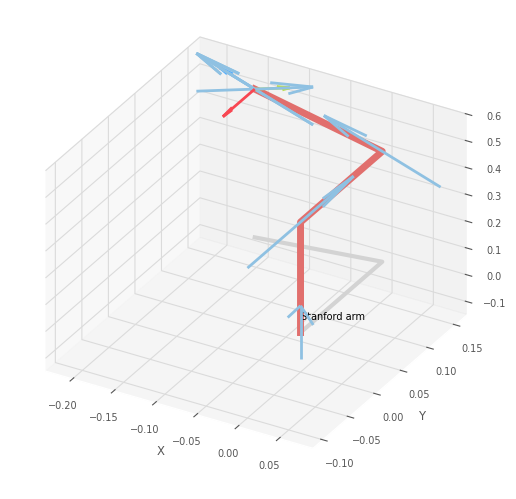

<Figure size 640x480 with 0 Axes>

In [1070]:
q_start = [0, -pi/4, 0.2, 0, 0, 0]
robot.plot(q_start)
plt.show()

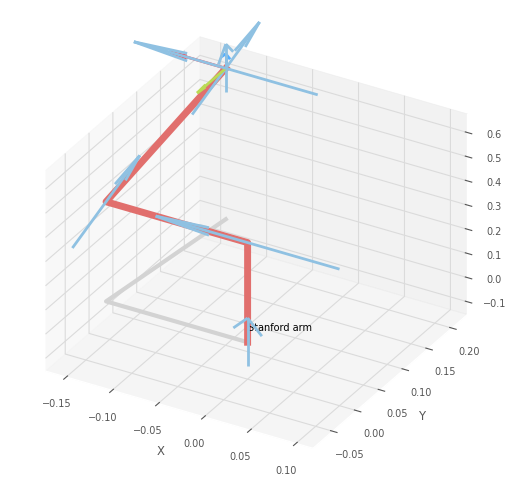

<Figure size 640x480 with 0 Axes>

In [1071]:
q_end = [pi/2, pi/4, 0.3, pi/2, -pi/4, pi/2]
robot.plot(q_end)
plt.show()

### 4. Plan the trajectory with prebuilt functions

In [1072]:
N = 150
t_start = 0
t_stop = 15
t_shag = t_stop/N
time = np.arange(t_start, t_stop, t_shag)
tr = rtb.jtraj(q_start, q_end, time)

### 5. Solve the inverse dynamics

In [1073]:
tau = robot.rne(tr.q, tr.qd, tr.qdd).T

tau0 = robot.rne(tr.q, np.zeros([N,6]), np.zeros([N,6])).T

tau_quasi = robot.rne(tr.q, tr.qd, np.zeros([N, 6])).T 


### 6. Obtain the components of the dynamic equation

In [1074]:
M = robot.inertia(tr.q)
C = robot.coriolis(tr.q, tr.qd)
G = robot.gravload(tr.q)

M0 = robot.inertia(tr.q)
C0 = robot.coriolis(tr.q, np.zeros([N,6]))
G0 = robot.gravload(tr.q)

In [1075]:
mid_idx = N // 2
q_mid = tr.q[mid_idx]
qd_mid = tr.qd[mid_idx]

# Compute components
M = robot.inertia(q_mid)          # Mass matrix (6x6)
C = robot.coriolis(q_mid, qd_mid) # Coriolis matrix (6x6)
G = robot.gravload(q_mid)         # Gravity vector (6,)

print("\nDynamic matrices at t:")
print("Mass matrix M(q):\n", np.round(M, 4))
print("Coriolis matrix C(q, qd):\n", np.round(C, 4))
print("Gravity vector G(q):\n",  G)


Dynamic matrices at t:
Mass matrix M(q):
 [[ 3.4600e+00 -4.4620e-01 -8.8000e-03  8.5000e-03 -2.0000e-03  9.0000e-04]
 [-4.4620e-01  3.4996e+00 -9.1000e-03 -5.6000e-03  6.1000e-03  3.0000e-04]
 [-8.8000e-03 -9.1000e-03  7.1100e+00  0.0000e+00  8.4000e-03  0.0000e+00]
 [ 8.5000e-03 -5.6000e-03 -0.0000e+00  1.3070e-01  0.0000e+00  9.0000e-04]
 [-2.0000e-03  6.1000e-03  8.4000e-03  0.0000e+00  1.2850e-01  0.0000e+00]
 [ 9.0000e-04  3.0000e-04  0.0000e+00  9.0000e-04  0.0000e+00  2.8000e-02]]
Coriolis matrix C(q, qd):
 [[ 3.100e-03 -7.100e-03 -1.751e-01  7.000e-04 -1.200e-03  0.000e+00]
 [-3.500e-03  3.350e-02  5.323e-01 -1.300e-03  2.300e-03 -0.000e+00]
 [-1.000e-04 -5.267e-01  0.000e+00  4.200e-03 -8.000e-04  0.000e+00]
 [ 2.000e-04  3.000e-04 -4.200e-03  1.000e-04 -3.000e-04  0.000e+00]
 [-5.000e-04 -1.100e-03  2.800e-03  3.000e-04  0.000e+00 -0.000e+00]
 [ 0.000e+00  0.000e+00  0.000e+00 -0.000e+00  0.000e+00  0.000e+00]]
Gravity vector G(q):
 [ 1.13725089e-16 -4.09143092e-01  6.346760

### 7. Plot the graphs

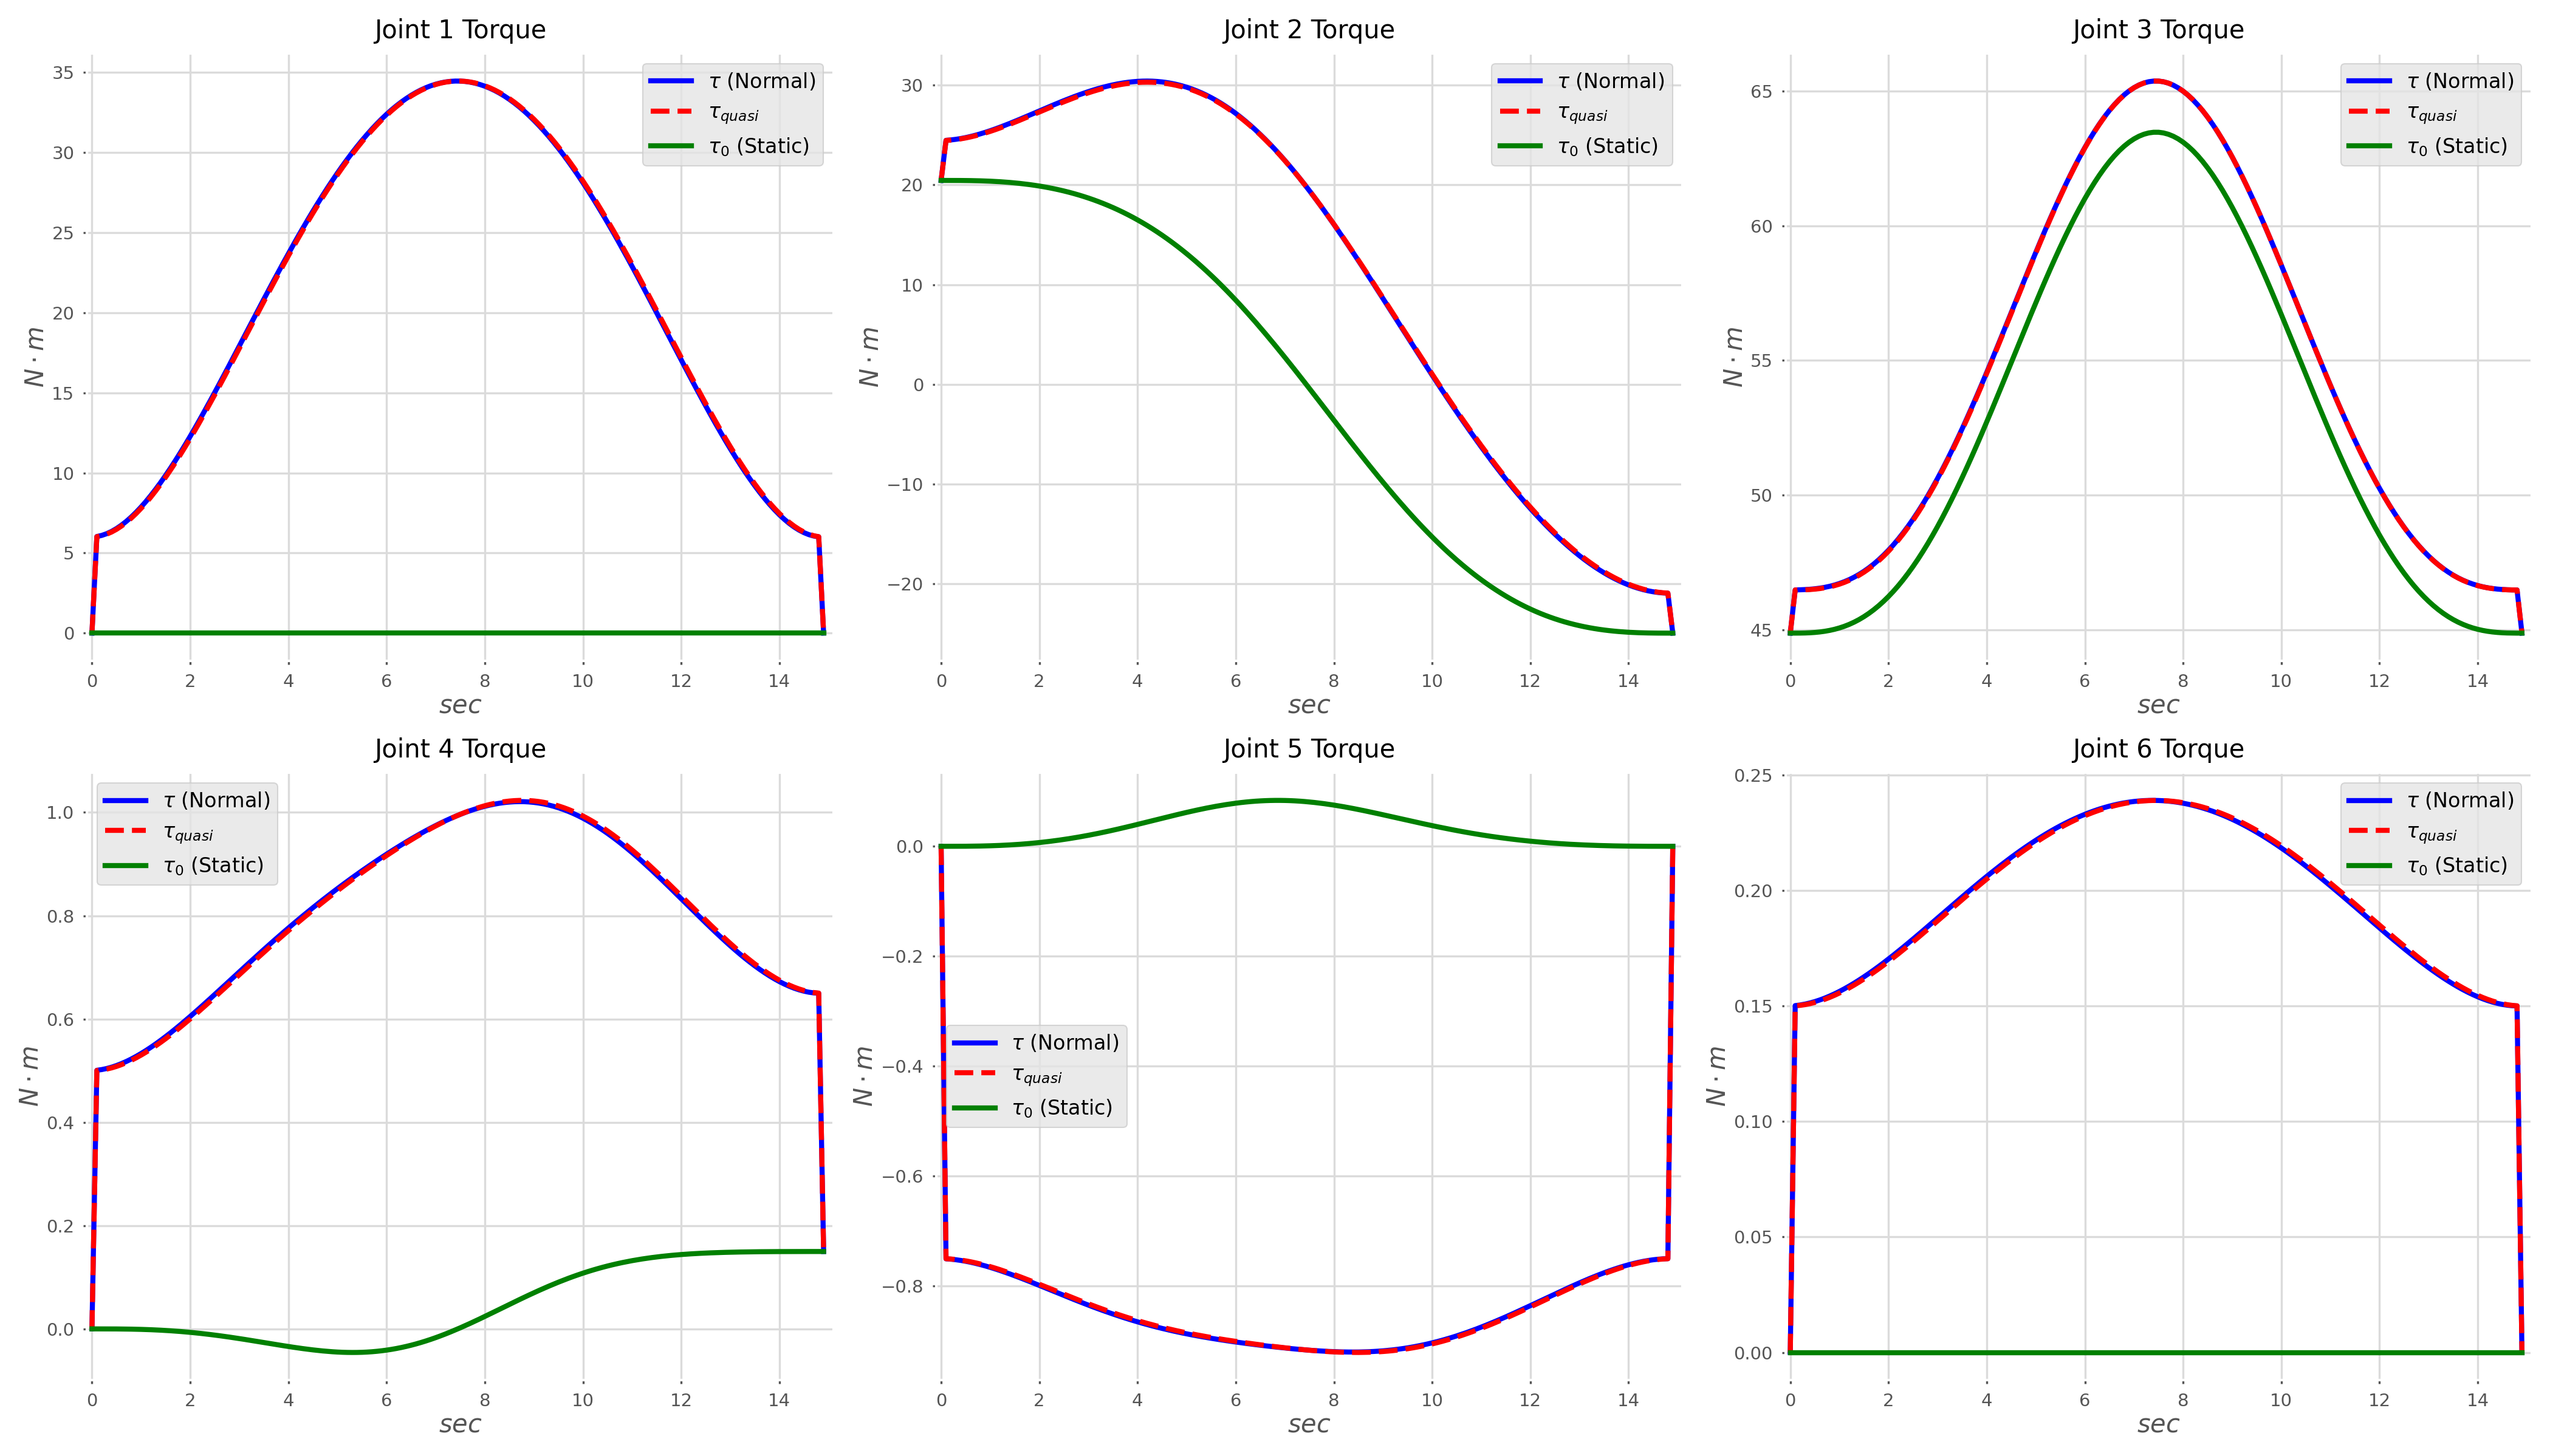

In [1077]:
plt.figure(figsize=(14, 8), dpi=300)
for i in range(6):
    plt.subplot(2,3,i+1)
    plt.plot(time, tau[i], 'b-', linewidth=2, label=r'$\tau$ (Normal)')
    plt.plot(time, tau_quasi[i], 'r--', linewidth=2, label=r'$\tau_{quasi}$')
    plt.plot(time, tau0[i], 'g-', linewidth=2, label=r'$\tau_0$ (Static)')
    plt.title(f'Joint {i+1} Torque', fontsize=10)
    plt.ylabel(r'$N \cdot m$', fontsize=10)
    plt.xlabel(r'$sec$', fontsize=10)
    plt.grid(True)
    plt.legend(fontsize=8)
    ax = plt.gca()
    ax.set_facecolor((1,1,1))
    ax.set_xlim([t_start-0.1,t_stop+0.1])
plt.tight_layout()
plt.show()